In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('realest.csv')

In [2]:
df.head()
df.tail()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      156 non-null    float64
 1   Bedroom    156 non-null    float64
 2   Space      146 non-null    float64
 3   Room       156 non-null    float64
 4   Lot        146 non-null    float64
 5   Tax        147 non-null    float64
 6   Bathroom   156 non-null    float64
 7   Garage     156 non-null    float64
 8   Condition  156 non-null    float64
dtypes: float64(9)
memory usage: 11.1 KB


(157, 9)

In [3]:
df.describe()

,Price,Bedroom,Space,Room,Lot,Tax,Bathroom,Garage,Condition
count,156.000000,156.000000,146.000000,156.000000,146.000000,147.000000,156.000000,156.000000,156.000000
mean,56.474359,3.166667,1097.246575,6.500000,32.808219,911.707483,1.480769,0.846154,0.230769
std,12.875307,1.348037,462.540698,1.675247,8.457859,443.263430,0.529408,0.808454,0.422682
min,32.000000,1.000000,539.000000,4.000000,24.000000,418.000000,1.000000,0.000000,0.000000
25%,46.000000,2.000000,805.250000,5.000000,25.000000,652.500000,1.000000,0.000000,0.000000
50%,55.000000,3.000000,965.500000,6.000000,30.000000,821.000000,1.500000,1.000000,0.000000
75%,65.000000,4.000000,1220.500000,7.000000,37.000000,1012.500000,2.000000,1.500000,0.000000
max,90.000000,8.000000,2295.000000,12.000000,50.000000,2752.000000,3.000000,2.000000,1.000000


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,156.0,56.474359,12.875307,32.0,46.00,55.0,65.0,90.0
Bedroom,156.0,3.166667,1.348037,1.0,2.00,3.0,4.0,8.0
Space,146.0,1097.246575,462.540698,539.0,805.25,965.5,1220.5,2295.0
Room,156.0,6.500000,1.675247,4.0,5.00,6.0,7.0,12.0
Lot,146.0,32.808219,8.457859,24.0,25.00,30.0,37.0,50.0
Tax,147.0,911.707483,443.263430,418.0,652.50,821.0,1012.5,2752.0
Bathroom,156.0,1.480769,0.529408,1.0,1.00,1.5,2.0,3.0
Garage,156.0,0.846154,0.808454,0.0,0.00,1.0,1.5,2.0
Condition,156.0,0.230769,0.422682,0.0,0.00,0.0,0.0,1.0


In [5]:
df.dtypes

Price        float64
Bedroom      float64
Space        float64
Room         float64
Lot          float64
Tax          float64
Bathroom     float64
Garage       float64
Condition    float64
dtype: object

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Price         1
Bedroom       1
Space        11
Room          1
Lot          11
Tax          10
Bathroom      1
Garage        1
Condition     1
dtype: int64

In [9]:
df.columns

Index(['Price', 'Bedroom', 'Space', 'Room', 'Lot', 'Tax', 'Bathroom', 'Garage',
       'Condition'],
      dtype='object')

In [11]:
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Bedroom'] = df['Bedroom'].fillna(df['Bedroom'].median())
df['Space'] = df['Space'].fillna(df['Space'].median())
df['Room'] = df['Room'].fillna(df['Room'].median())
df['Lot'] = df['Lot'].fillna(df['Lot'].median())
df['Tax'] = df['Tax'].fillna(df['Tax'].median())
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Garage'] = df['Garage'].fillna(df['Garage'].median())
df['Condition'] = df['Condition'].fillna(df['Condition'].median())


In [12]:
df.isnull().sum()

Price        0
Bedroom      0
Space        0
Room         0
Lot          0
Tax          0
Bathroom     0
Garage       0
Condition    0
dtype: int64

In [ ]:
df.to_csv('Cleaned_Ho')

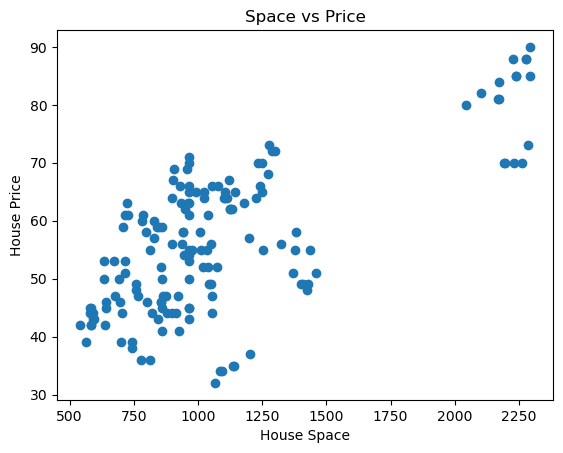

In [23]:
# Outliers
plt.scatter(df['Space'], df['Price'])
plt.xlabel('House Space')
plt.ylabel('House Price')
plt.title('Space vs Price')
plt.show()

In [16]:
x = df.drop('Price', axis = 1)
y = df['Price']

In [17]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [18]:
# Train regession model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
# Predict prices
predictions = model.predict(X_test)
print(predictions)

[42.48089766 44.57795702 59.06455395 65.37706325 75.37880717 59.11643378
 64.68401729 47.87996013 56.79730971 80.98461625 48.01904703 68.42926959
 45.41892865 66.30638375 56.91632681 66.85606757 48.93471615 67.12885762
 57.44815369 45.72303667 48.45186194 55.04985443 44.15519056 76.47256018
 59.54663    58.90970081 61.20678359 56.51545733 41.74251524 42.74426019
 47.62449008 52.07171354]
